# Relatório - Visão Computacional e Aprendizado Profundo


## Programa de Pós-Graduação em Informática (PPGIa) / PUCPR (2026-2)

**Prof. Rayson Laroca**

`Thiago Costa` - `thiagohesc@gmail.com`

# Importe as bibliotecas necessárias

In [104]:
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub
import math
import re
import numpy as np

from time import perf_counter
from pathlib import Path
from PIL import Image, ImageStat, ImageOps
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray, rgb2hsv
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import make_pipeline

# 1. Defina a tarefa e o conjunto de dados

## Problema de Classificação

O projeto tem como objetivo desenvolver e avaliar métodos de **classificação de espécies de aves a partir de imagens**, utilizando: abordagens tradicionais de processamento de imagens, aprendizado de máquina e aprendizado profundo.

## Conjunto de Dados

Será utilizado o conjunto de dados **Caltech-UCSD Birds-200-2011 (CUB-200-2011)**, desenvolvido para pesquisas relacionadas à classificação visual de espécies de aves.

## Características do Conjunto de Dados

- **Número de classes:** 200 espécies de aves;
- **Número total de imagens:** 11.788;
- **Localizações de partes por imagem:** 15;
- **Atributos binários por imagem:** 312;
- **Caixa delimitadora (*Bounding Box*) por imagem:** 1.

## Objetivo da Classificação

O objetivo principal é desenvolver modelos capazes de receber como entrada uma imagem contendo uma ave e identificar corretamente **a qual das 200 espécies disponíveis no conjunto de dados ela pertence**.

## Fonte do Conjunto de Dados

O conjunto de dados utilizado neste projeto está disponível publicamente no Kaggle:

https://www.kaggle.com/datasets/wenewone/cub2002011

Informações detalhadas sobre o conjunto de dados original podem ser encontradas no relatório técnico disponibilizado pelo Caltech:

https://authors.library.caltech.edu/27452/

# 2. Aquisição do conjunto de dados

O conjunto é obtido pelo Kaggle e validado a partir dos arquivos oficiais de classes, imagens, rótulos, divisão de treino/teste e bbox. A preparação reúne esses arquivos em uma tabela e verifica identificadores, relacionamentos, dimensões e disponibilidade das imagens.

Nesta etapa, são mantidas todas as 11.788 imagens, em suas resoluções originais, sem subamostragem ou redimensionamento. As imagens são lidas individualmente para extrair informações, evitando carregar todo o conjunto simultaneamente na memória. As transformações para os modelos serão definidas na Etapa 5.

Execute o notebook a partir da raiz do repositório. O download é opcional (`DOWNLOAD = False`), pois os dados já estão disponíveis localmente.

O CUB-200-2011 permite estudar classificação: espécies diferentes podem ter aparência semelhante, enquanto aves da mesma espécie variam em pose, iluminação e fundo. Esse cenário permite comparar descritores tradicionais com representações aprendidas por redes neurais.

In [105]:
"""
Obtenção do conjunto de dados pelo Kaggle
Se True, o código fará o download do conjunto de dados CUB-200-2011 do Kaggle e o salvará no diretório ./data/raw.
"""
DOWNLOAD = True

# Definir uma semente para reprodutibilidade Global
SEED = 42

if DOWNLOAD:
    DATA_DIR = Path("./data/raw")
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    dataset_path = kagglehub.dataset_download(
        "wenewone/cub2002011", output_dir=str(DATA_DIR)
    )

    print(f"Dataset disponível em: {dataset_path}")

"""
Extrair metadados do conjunto de dados CUB-200-2011 e salvar em um arquivo CSV.
O arquivo CSV conterá informações sobre as imagens, classes, rótulos, divisão entre treino e teste, e bounding boxes.
"""
# Classes
df_classes = pd.read_csv(
    DATA_DIR / "CUB_200_2011" / "classes.txt",
    sep=r"\s+",
    names=["class_id", "class_name"],
)

# Imagens
df_images = pd.read_csv(
    DATA_DIR / "CUB_200_2011" / "images.txt",
    sep=r"\s+",
    names=["image_id", "image_path"],
)

# Relação entre imagens e classes
df_labels = pd.read_csv(
    DATA_DIR / "CUB_200_2011" / "image_class_labels.txt",
    sep=r"\s+",
    names=["image_id", "class_id"],
)

# Divisão entre treino e teste (1 = treino; 0 = teste)
df_split = pd.read_csv(
    DATA_DIR / "CUB_200_2011" / "train_test_split.txt",
    sep=r"\s+",
    names=["image_id", "image_split"],
)

# Bounding boxes
df_bounding_boxes = pd.read_csv(
    DATA_DIR / "CUB_200_2011" / "bounding_boxes.txt",
    sep=r"\s+",
    names=[
        "image_id",
        "bbox_x",
        "bbox_y",
        "bbox_width",
        "bbox_height",
    ],
)

df_metadados = (
    df_images.merge(
        df_labels,
        on="image_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        df_split,
        on="image_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        df_bounding_boxes,
        on="image_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        df_classes,
        on="class_id",
        how="left",
        validate="many_to_one",
    )
)

df_metadados = df_metadados.astype(
    {
        "image_id": "int32",
        "image_path": "string",
        "class_id": "int16",
        "image_split": "int8",
        "bbox_x": "float32",
        "bbox_y": "float32",
        "bbox_width": "float32",
        "bbox_height": "float32",
        "class_name": "string",
    },
)

df_metadados.to_csv(
    DATA_DIR / "CUB_200_2011" / "metadados.csv",
    index=False,
)

print(f"Metadados disponíveis em: {DATA_DIR / 'CUB_200_2011' / 'metadados.csv'}")
df_metadados.head()

Dataset disponível em: data/raw
Metadados disponíveis em: data/raw/CUB_200_2011/metadados.csv


,image_id,image_path,class_id,image_split,bbox_x,bbox_y,bbox_width,bbox_height,class_name
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,60.0,27.0,325.0,304.0,001.Black_footed_Albatross
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,139.0,30.0,153.0,264.0,001.Black_footed_Albatross
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,1,0,14.0,112.0,388.0,186.0,001.Black_footed_Albatross
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,112.0,90.0,255.0,242.0,001.Black_footed_Albatross
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,70.0,50.0,134.0,303.0,001.Black_footed_Albatross


# 3. Análise e visualização do conjunto de dados

O conjunto apresenta boa distribuição entre as 200 classes. A quantidade de imagens por classe varia de 41 a 60, com média de 58,94 e mediana de 60 imagens, indicando um conjunto relativamente balanceado. Isso reduz a tendência de o modelo favorecer determinadas espécies apenas por possuírem mais exemplos.

As imagens, porém, apresentam variações importantes de resolução. As larguras variam de 121 a 500 pixels e as alturas de 120 a 500 pixels, com grande concentração de imagens próximas ao limite de 500 pixels. Imagens com menor resolução podem dificultar a identificação de detalhes como padrões da plumagem, formato do bico e características das asas, que são importantes para distinguir espécies visualmente semelhantes.

Também foram identificados casos extremos de iluminação e diferenças na proporção ocupada pela bbox. Imagens muito claras ou escuras podem esconder características relevantes da ave, enquanto uma bbox pequena indica que o objeto ocupa uma parte reduzida da cena, aumentando a presença de fundo. Isso pode dificultar o aprendizado e fazer com que o modelo utilize características do ambiente em vez da própria ave.

Por se tratar de um problema de classificação fina, a similaridade visual entre espécies também representa um desafio. Pequenas diferenças podem determinar a classe correta, enquanto fatores como iluminação, resolução, pose, escala e possíveis oclusões podem tornar essas diferenças menos perceptíveis.

Na análise realizada e na inspeção visual das amostras, não foram identificados indícios evidentes de desequilíbrio significativo ou problemas sistemáticos de qualidade e rotulagem.

### Estatísticas básicas

In [106]:
# Validação e numero total de imagens
imagens_existentes = df_metadados["image_path"].apply(
    lambda path: (DATA_DIR / "CUB_200_2011" / "images" / path).is_file()
)
total_imagens = len(df_metadados)
print(f"Total de imagens existentes: {imagens_existentes.sum()} de {total_imagens}")


# Extrair informações das imagens
def extrair_informacoes_imagem(image_path):
    path = DATA_DIR / "CUB_200_2011" / "images" / image_path
    with Image.open(path) as image:
        return pd.Series(
            {
                "image_width": image.width,
                "image_height": image.height,
                "image_format": image.format,
            }
        )


df_image_info = df_metadados["image_path"].apply(extrair_informacoes_imagem)

df_metadados = pd.concat(
    [df_metadados, df_image_info],
    axis=1,
)

# Faixas de largura e altura das imagens
largura_min = df_metadados["image_width"].min()
largura_max = df_metadados["image_width"].max()

altura_min = df_metadados["image_height"].min()
altura_max = df_metadados["image_height"].max()

print("Largura mínima:", largura_min)
print("Largura máxima:", largura_max)

print("Altura mínima:", altura_min)
print("Altura máxima:", altura_max)

# Validação e numero total de classes
classes_existentes = df_metadados.loc[imagens_existentes, "class_id"].unique()
total_classes = df_metadados["class_id"].nunique()
print(f"Total de classes existentes: {len(classes_existentes)} de {total_classes}")

Total de imagens existentes: 11788 de 11788
Largura mínima: 121
Largura máxima: 500
Altura mínima: 120
Altura máxima: 500
Total de classes existentes: 200 de 200


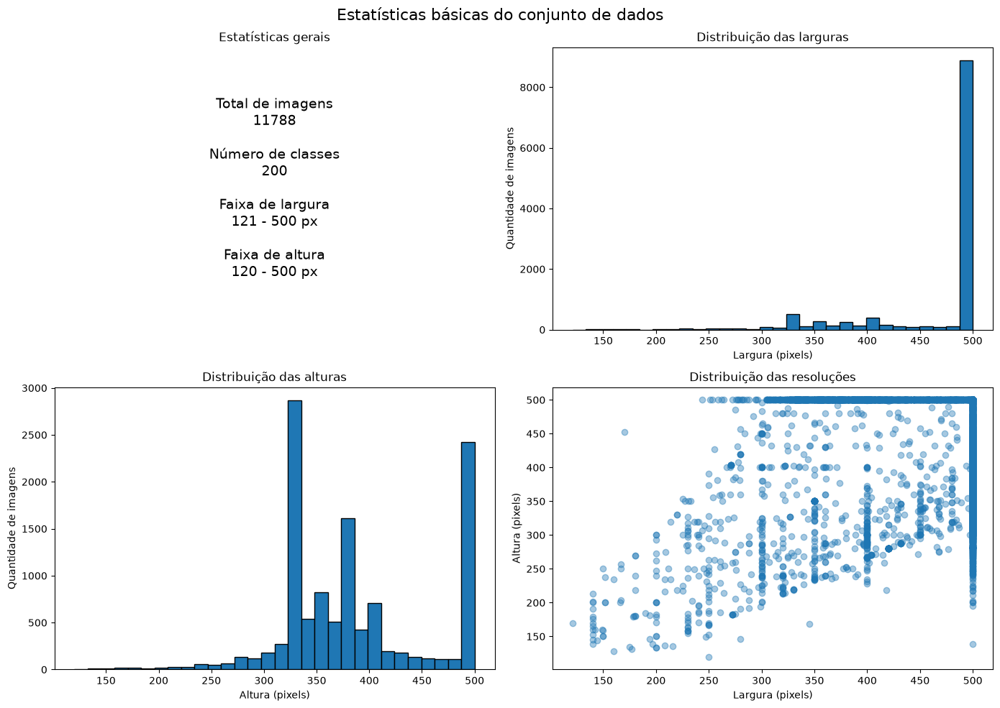

In [107]:
# Plotar estatísticas básicas do conjunto de dados
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].axis("off")

texto = (
    f"Total de imagens\n"
    f"{total_imagens}\n\n"
    f"Número de classes\n"
    f"{total_classes}\n\n"
    f"Faixa de largura\n"
    f"{largura_min} - {largura_max} px\n\n"
    f"Faixa de altura\n"
    f"{altura_min} - {altura_max} px"
)

axes[0, 0].text(
    0.5,
    0.5,
    texto,
    horizontalalignment="center",
    verticalalignment="center",
    fontsize=14,
)

axes[0, 0].set_title("Estatísticas gerais")

axes[0, 1].hist(df_metadados["image_width"], bins=30, edgecolor="black")

axes[0, 1].set_title("Distribuição das larguras")
axes[0, 1].set_xlabel("Largura (pixels)")
axes[0, 1].set_ylabel("Quantidade de imagens")

axes[1, 0].hist(df_metadados["image_height"], bins=30, edgecolor="black")

axes[1, 0].set_title("Distribuição das alturas")
axes[1, 0].set_xlabel("Altura (pixels)")
axes[1, 0].set_ylabel("Quantidade de imagens")

axes[1, 1].scatter(df_metadados["image_width"], df_metadados["image_height"], alpha=0.4)

axes[1, 1].set_title("Distribuição das resoluções")
axes[1, 1].set_xlabel("Largura (pixels)")
axes[1, 1].set_ylabel("Altura (pixels)")


plt.suptitle("Estatísticas básicas do conjunto de dados", fontsize=16)

plt.tight_layout()
plt.show()

### Distribuição das classes

In [108]:
# Distribuição de imagens por classe
distribuicao_classes = df_metadados["class_id"].value_counts().sort_index()
distribuicao_classes.describe()

count    200.000000
mean      58.940000
std        2.918732
min       41.000000
25%       59.000000
50%       60.000000
75%       60.000000
max       60.000000
Name: count, dtype: float64

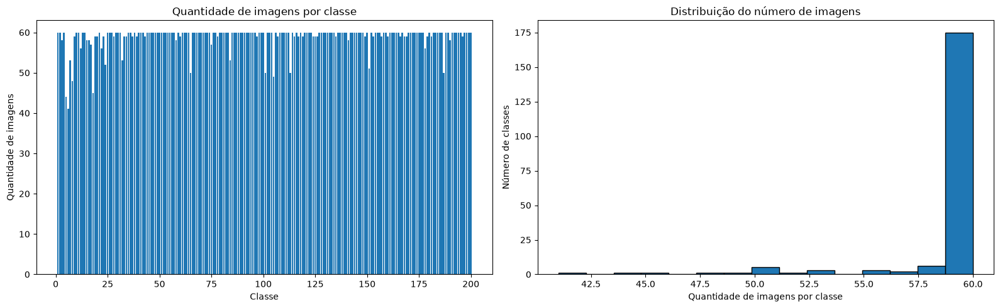

In [109]:
# Plotar distribuição de imagens por classe
distribuicao_classes = df_metadados["class_id"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# Quantidade de imagens por classe
axes[0].bar(distribuicao_classes.index, distribuicao_classes.values)

axes[0].set_title("Quantidade de imagens por classe")
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Quantidade de imagens")


# Histograma
axes[1].hist(distribuicao_classes.values, bins=15, edgecolor="black")

axes[1].set_title("Distribuição do número de imagens")
axes[1].set_xlabel("Quantidade de imagens por classe")
axes[1].set_ylabel("Número de classes")


plt.tight_layout()
plt.show()

### Exemplos

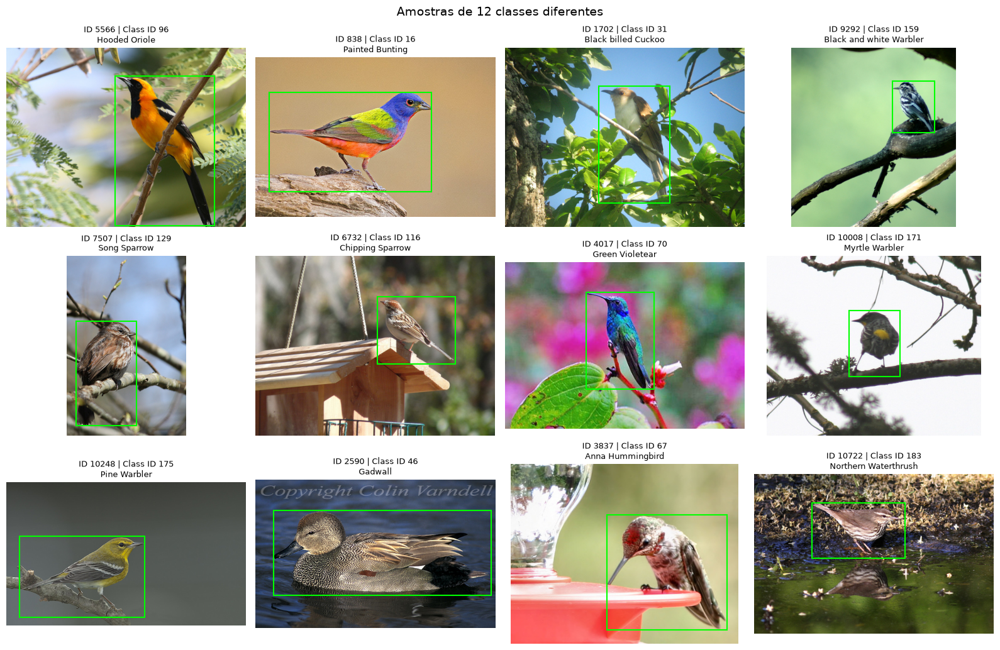

In [110]:
# Função para exibir amostras de imagens com bounding boxes
def exibir_amostras(amostras, titulo, colunas=4):
    if amostras.empty:
        print("Nenhuma imagem para exibir.")
        return

    linhas = math.ceil(len(amostras) / colunas)

    fig, axes = plt.subplots(
        linhas, colunas, figsize=(4 * colunas, 3.5 * linhas), squeeze=False
    )

    for ax in axes.flat:
        ax.axis("off")

    # Exibe as imagens
    for ax, (_, registro) in zip(axes.flat, amostras.iterrows()):
        try:
            with Image.open(
                DATA_DIR / "CUB_200_2011" / "images" / registro["image_path"]
            ) as imagem:
                ax.imshow(imagem.convert("RGB"))

            ax.add_patch(
                Rectangle(
                    (registro["bbox_x"], registro["bbox_y"]),
                    registro["bbox_width"],
                    registro["bbox_height"],
                    fill=False,
                    edgecolor="lime",
                    linewidth=1.5,
                )
            )

            nome = re.sub(r"^\d+\.", "", registro["class_name"]).replace("_", " ")

            ax.set_title(
                f"ID {registro['image_id']} | Class ID {registro['class_id']}\n{nome}",
                fontsize=9,
            )

        except (OSError, ValueError) as erro:
            ax.set_title(f"ID {registro['image_id']}: {type(erro).__name__}")

    fig.suptitle(titulo, fontsize=14)

    plt.tight_layout()
    plt.show()


# Exemplos de classes diferentes
classes_amostra = (
    df_metadados["class_id"].drop_duplicates().sample(12, random_state=SEED)
)
amostras = pd.concat(
    [
        df_metadados[df_metadados["class_id"] == classe].sample(1, random_state=SEED)
        for classe in classes_amostra
    ]
)

exibir_amostras(amostras, "Amostras de 12 classes diferentes")

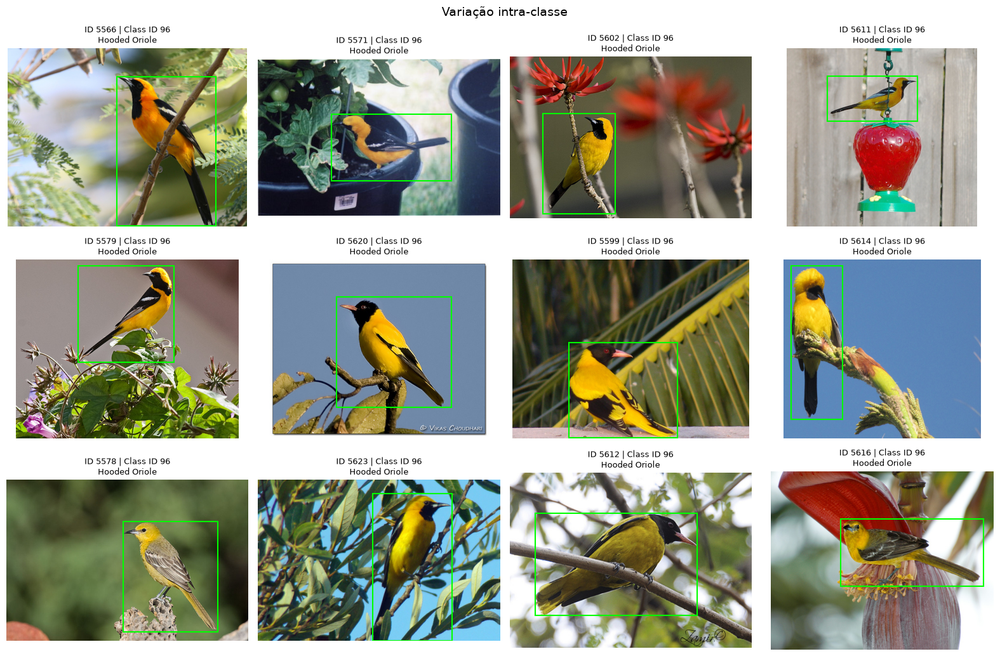

In [111]:
# Exemplos de variação intra-classe
classe_amostra = (
    df_metadados["class_id"].drop_duplicates().sample(1, random_state=SEED).iloc[0]
)

amostras = df_metadados[df_metadados["class_id"] == classe_amostra].sample(
    12, random_state=SEED
)

exibir_amostras(amostras, "Variação intra-classe")

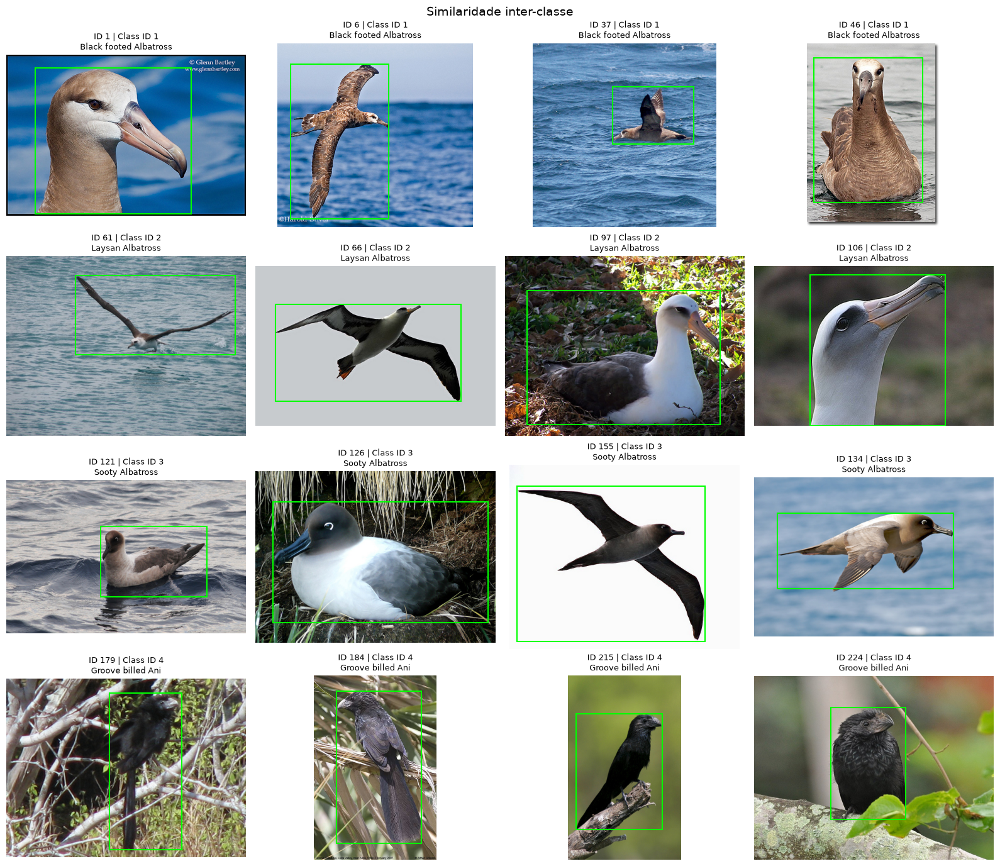

In [112]:
# Exemplos de classes visualmente similares
classes_comparacao = [1, 2, 3, 4]

amostras = pd.concat(
    [
        df_metadados[df_metadados["class_id"] == classe].sample(
            min(4, len(df_metadados[df_metadados["class_id"] == classe])),
            random_state=SEED,
        )
        for classe in classes_comparacao
    ]
)

exibir_amostras(amostras, "Similaridade inter-classe", colunas=4)

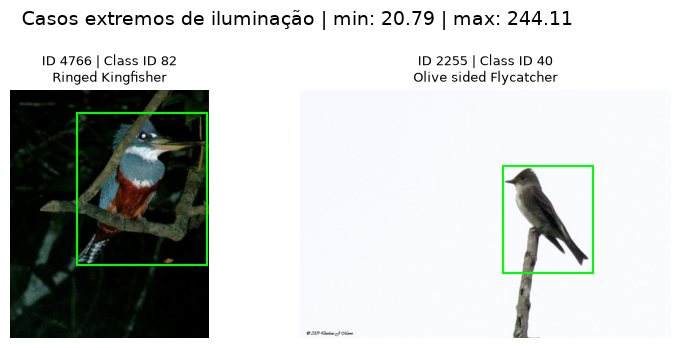

In [113]:
def calcular_iluminacao(image_path):
    try:
        caminho = DATA_DIR / "CUB_200_2011" / "images" / image_path

        with Image.open(caminho) as imagem:
            imagem_cinza = imagem.convert("L")
            return ImageStat.Stat(imagem_cinza).mean[0]

    except (OSError, ValueError):
        return None


# Iluminação
df_metadados["brightness"] = df_metadados["image_path"].apply(calcular_iluminacao)


# Resolução da imagem
df_metadados["resolution"] = df_metadados["image_width"] * df_metadados["image_height"]


# Área da bounding box
df_metadados["bbox_area"] = df_metadados["bbox_width"] * df_metadados["bbox_height"]


# Área da imagem
df_metadados["image_area"] = df_metadados["image_width"] * df_metadados["image_height"]


# Proporção da imagem ocupada pela bounding box
df_metadados["bird_ratio"] = df_metadados["bbox_area"] / df_metadados["image_area"]


df_brightness = df_metadados.dropna(subset=["brightness"])

menor_iluminacao = df_brightness.loc[df_brightness["brightness"].idxmin()].copy()

maior_iluminacao = df_brightness.loc[df_brightness["brightness"].idxmax()].copy()

menor_resolucao = df_metadados.loc[df_metadados["resolution"].idxmin()].copy()

maior_resolucao = df_metadados.loc[df_metadados["resolution"].idxmax()].copy()

menor_bbox = df_metadados.loc[df_metadados["bird_ratio"].idxmin()].copy()

maior_bbox = df_metadados.loc[df_metadados["bird_ratio"].idxmax()].copy()


# Identificar cada exemplo
menor_iluminacao["analise"] = "Menor iluminação"
maior_iluminacao["analise"] = "Maior iluminação"

menor_resolucao["analise"] = "Menor resolução"
maior_resolucao["analise"] = "Maior resolução"

menor_bbox["analise"] = "Menor bbox"
maior_bbox["analise"] = "Maior bbox"


# Criar DataFrame com os casos extremos
amostras_extremos = pd.DataFrame(
    [
        menor_iluminacao,
        maior_iluminacao,
        menor_resolucao,
        maior_resolucao,
        menor_bbox,
        maior_bbox,
    ]
)

amostras_extremos[
    [
        "analise",
        "image_id",
        "class_name",
        "image_width",
        "image_height",
        "brightness",
        "resolution",
        "bird_ratio",
    ]
]

exibir_amostras(
    amostras_extremos[
        amostras_extremos["analise"].isin(["Menor iluminação", "Maior iluminação"])
    ],
    (
        f"Casos extremos de iluminação | "
        f"min: {df_metadados['brightness'].min():.2f} | "
        f"max: {df_metadados['brightness'].max():.2f}"
    ),
    colunas=2,
)

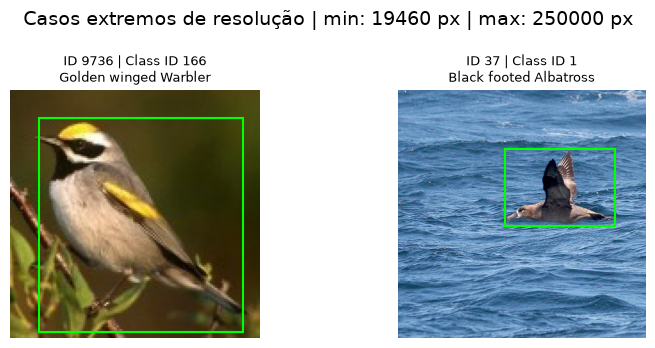

In [114]:
exibir_amostras(
    amostras_extremos[
        amostras_extremos["analise"].isin(["Menor resolução", "Maior resolução"])
    ],
    (
        f"Casos extremos de resolução | "
        f"min: {int(df_metadados['resolution'].min())} px | "
        f"max: {int(df_metadados['resolution'].max())} px"
    ),
    colunas=2,
)

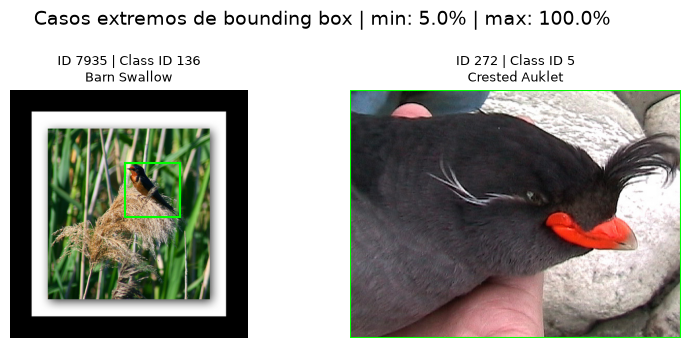

In [115]:
exibir_amostras(
    amostras_extremos[amostras_extremos["analise"].isin(["Menor bbox", "Maior bbox"])],
    (
        f"Casos extremos de bounding box | "
        f"min: {df_metadados['bird_ratio'].min():.1%} | "
        f"max: {df_metadados['bird_ratio'].max():.1%}"
    ),
    colunas=2,
)

### Divisão do conjunto de dados

O CUB-200-2011 possui uma divisão oficial com 5.994 imagens para treino e 5.794 para teste, distribuídas entre 200 classes.

Como o dataset não possui um conjunto de validação, o conjunto de teste será mantido apenas para a avaliação final. Para validação, será utilizado 20% do conjunto oficial de treino, com divisão estratificada por classe, deixando os 80% restantes para treinamento.

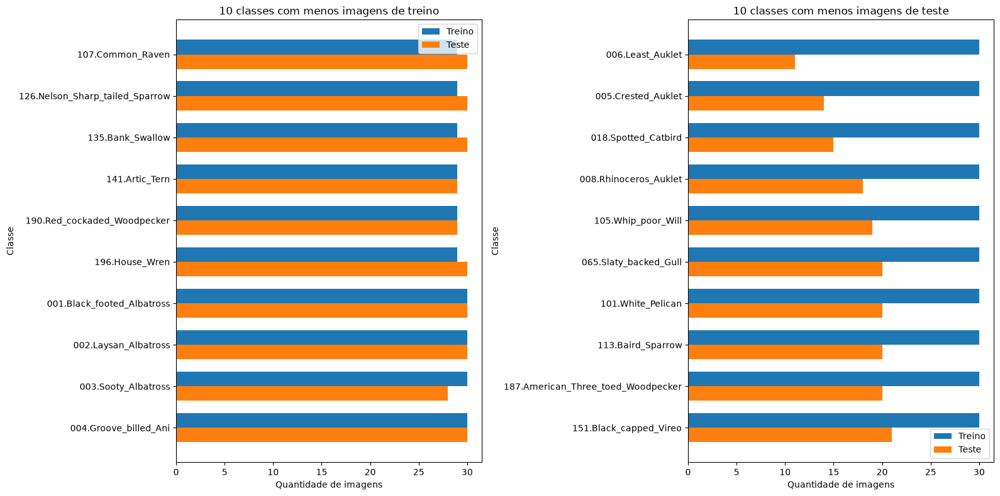

In [116]:
df_metadados["split"] = df_metadados["image_split"].map({1: "Treino", 0: "Teste"})
df_metadados["aspect_ratio"] = (
    df_metadados["image_width"] / df_metadados["image_height"]
)

resumo = pd.Series(
    {
        "Imagens": len(df_metadados),
        "Classes": df_metadados["class_id"].nunique(),
        "Treino": (df_metadados["split"] == "Treino").sum(),
        "Teste": (df_metadados["split"] == "Teste").sum(),
        "Formatos distintos": df_metadados["image_format"].nunique(),
        "Valores ausentes": df_metadados.isna().sum().sum(),
    },
    name="Quantidade",
)

# Quantidade de imagens por classe e por conjunto
por_split = pd.crosstab(df_metadados["class_name"], df_metadados["split"])

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

altura = 0.35

# 10 classes com menos imagens de treino
menos_treino = por_split.nsmallest(10, "Treino")

y = np.arange(len(menos_treino))

axes[0].barh(y - altura / 2, menos_treino["Treino"], height=altura, label="Treino")

axes[0].barh(y + altura / 2, menos_treino["Teste"], height=altura, label="Teste")

axes[0].set_yticks(y)
axes[0].set_yticklabels(menos_treino.index)

axes[0].set(
    title="10 classes com menos imagens de treino",
    xlabel="Quantidade de imagens",
    ylabel="Classe",
)

axes[0].invert_yaxis()
axes[0].legend()

# 10 classes com menos imagens de teste
menos_teste = por_split.nsmallest(10, "Teste")

y = np.arange(len(menos_teste))

axes[1].barh(y - altura / 2, menos_teste["Treino"], height=altura, label="Treino")

axes[1].barh(y + altura / 2, menos_teste["Teste"], height=altura, label="Teste")

axes[1].set_yticks(y)
axes[1].set_yticklabels(menos_teste.index)

axes[1].set(
    title="10 classes com menos imagens de teste",
    xlabel="Quantidade de imagens",
    ylabel="Classe",
)

axes[1].invert_yaxis()
axes[1].legend()


plt.tight_layout()
plt.show()

# 4. Divisão do conjunto de dados

Como o dataset não possui um conjunto de validação, 20% do conjunto oficial de treino será separado para essa finalidade. A divisão será estratificada por classe, para manter a distribuição das espécies, enquanto o conjunto de teste será preservado apenas para a avaliação final do modelo.

In [117]:
indices_treino = df_metadados[df_metadados["image_split"] == 1].index

_, indices_validacao = train_test_split(
    indices_treino,
    test_size=0.20,
    random_state=SEED,
    stratify=df_metadados.loc[indices_treino, "class_id"],
)

df_metadados.loc[indices_validacao, "image_split"] = 2

df_metadados["split"] = df_metadados["image_split"].map(
    {0: "Teste", 1: "Treino", 2: "Validação"}
)

df_metadados.to_csv(
    DATA_DIR / "CUB_200_2011" / "metadados.csv",
    index=False,
)
df_metadados["split"].value_counts()

split
Teste        5794
Treino       4795
Validação    1199
Name: count, dtype: int64

# 5. Pré-processamento de imagens

As imagens foram convertidas para RGB e padronizadas para 384 × 384 pixels. Como o conjunto possui diferentes resoluções e proporções, o redimensionamento foi realizado preservando a proporção original e adicionando preenchimento quando necessário. Dessa forma, evita-se deformar características importantes das aves.

A resolução de 384 × 384 foi escolhida para preservar detalhes como plumagem, bico e padrões das asas, importantes neste problema de classificação fina, mantendo ao mesmo tempo um custo computacional compatível com o hardware utilizado e com a arquitetura de aprendizado profundo escolhida.

Além da padronização das imagens, foi aplicada uma estratégia de aumento de dados offline no conjunto de treinamento. Para cada imagem original, foi gerada uma segunda versão utilizando a bounding box disponibilizada pelo dataset, mantendo apenas a região da ave. Dessa forma, o treinamento poderá utilizar tanto a imagem completa, que preserva o contexto da cena, quanto a versão recortada, que destaca as características da ave e reduz a influência do fundo.

Os conjuntos de validação e teste foram mantidos somente com imagens completas, sem aumento de dados, permitindo avaliar os modelos sobre imagens próximas às condições originais do conjunto.


In [118]:
# Pre-processamento das imagens: redimensionamento e salvamento em diretórios separados para treino, validação e teste.
IMG_SIZE = (384, 384)

PROCESSED_DIR = Path("./data/processed")
IMAGES_DIR = DATA_DIR / "CUB_200_2011" / "images"
TRAIN_FULL_DIR = PROCESSED_DIR / "train" / "full"
TRAIN_BBOX_DIR = PROCESSED_DIR / "train" / "bbox"

VALIDATION_FULL_DIR = PROCESSED_DIR / "validation" / "full"

TEST_FULL_DIR = PROCESSED_DIR / "test" / "full"


def redimensionar_imagem(imagem, tamanho=IMG_SIZE):
    """
    Redimensiona uma imagem para o tamanho especificado.
    """
    return ImageOps.pad(
        imagem, tamanho, method=Image.Resampling.LANCZOS, color=(0, 0, 0)
    )


def processar_full(caminho_entrada, caminho_saida):
    caminho_saida.parent.mkdir(parents=True, exist_ok=True)

    with Image.open(caminho_entrada) as imagem:
        imagem = imagem.convert("RGB")

        imagem = redimensionar_imagem(imagem)

        imagem.save(caminho_saida, quality=95)


def recortar_bbox(imagem, registro):
    largura_imagem, altura_imagem = imagem.size

    x1 = int(registro["bbox_x"])
    y1 = int(registro["bbox_y"])

    x2 = int(registro["bbox_x"] + registro["bbox_width"])

    y2 = int(registro["bbox_y"] + registro["bbox_height"])

    x1 = max(0, x1)
    y1 = max(0, y1)

    x2 = min(largura_imagem, x2)
    y2 = min(altura_imagem, y2)

    if x2 <= x1 or y2 <= y1:
        raise ValueError(f"Bounding box inválida para a imagem {registro['image_id']}")

    return imagem.crop((x1, y1, x2, y2))


def processar_bbox(registro, caminho_entrada, caminho_saida):
    caminho_saida.parent.mkdir(parents=True, exist_ok=True)

    with Image.open(caminho_entrada) as imagem:
        imagem = imagem.convert("RGB")

        imagem = recortar_bbox(imagem, registro)

        imagem = redimensionar_imagem(imagem)

        imagem.save(caminho_saida, quality=95)


registros_processados = []

for _, registro in df_metadados.iterrows():
    caminho_original = IMAGES_DIR / registro["image_path"]

    # TREINO
    if registro["split"] == "Treino":
        caminho_full = TRAIN_FULL_DIR / registro["image_path"]

        caminho_bbox = TRAIN_BBOX_DIR / registro["image_path"]

        processar_full(caminho_original, caminho_full)

        processar_bbox(registro, caminho_original, caminho_bbox)

        registros_processados.append(
            {
                "image_id": registro["image_id"],
                "class_id": registro["class_id"],
                "class_name": registro["class_name"],
                "split": "Treino",
                "variant": "full",
                "image_path": str(caminho_full.relative_to(PROCESSED_DIR)),
            }
        )

        registros_processados.append(
            {
                "image_id": registro["image_id"],
                "class_id": registro["class_id"],
                "class_name": registro["class_name"],
                "split": "Treino",
                "variant": "bbox",
                "image_path": str(caminho_bbox.relative_to(PROCESSED_DIR)),
            }
        )

    # VALIDAÇÃO
    elif registro["split"] == "Validação":
        caminho_full = VALIDATION_FULL_DIR / registro["image_path"]

        processar_full(caminho_original, caminho_full)

        registros_processados.append(
            {
                "image_id": registro["image_id"],
                "class_id": registro["class_id"],
                "class_name": registro["class_name"],
                "split": "Validação",
                "variant": "full",
                "image_path": str(caminho_full.relative_to(PROCESSED_DIR)),
            }
        )

    # TESTE
    elif registro["split"] == "Teste":
        caminho_full = TEST_FULL_DIR / registro["image_path"]

        processar_full(caminho_original, caminho_full)

        registros_processados.append(
            {
                "image_id": registro["image_id"],
                "class_id": registro["class_id"],
                "class_name": registro["class_name"],
                "split": "Teste",
                "variant": "full",
                "image_path": str(caminho_full.relative_to(PROCESSED_DIR)),
            }
        )

df_processado = pd.DataFrame(registros_processados)
df_processado.to_csv(PROCESSED_DIR / "metadados.csv", index=False)
df_processado.head()

,image_id,class_id,class_name,split,variant,image_path
0,1,1,001.Black_footed_Albatross,Teste,full,test/full/001.Black_footed_Albatross/Black_Foo...
1,2,1,001.Black_footed_Albatross,Treino,full,train/full/001.Black_footed_Albatross/Black_Fo...
2,2,1,001.Black_footed_Albatross,Treino,bbox,train/bbox/001.Black_footed_Albatross/Black_Fo...
3,3,1,001.Black_footed_Albatross,Teste,full,test/full/001.Black_footed_Albatross/Black_Foo...
4,4,1,001.Black_footed_Albatross,Validação,full,validation/full/001.Black_footed_Albatross/Bla...


In [119]:
# Conferindo a distribuição de imagens por conjunto e variante
pd.crosstab(df_processado["split"], df_processado["variant"])

variant,bbox,full
split,,
Teste,0,5794
Treino,4795,4795
Validação,0,1199


Não foram aplicadas conversões para escala de cinza, filtros de redução de ruído ou correções fixas de brilho e contraste. A cor e os pequenos detalhes visuais são importantes para diferenciar espécies semelhantes, e alterações desse tipo poderiam remover informações relevantes.

A normalização dos pixels também não foi aplicada diretamente às imagens salvas. Essa etapa será realizada durante o treinamento, de acordo com o pré-processamento exigido pelo modelo utilizado. Outras transformações, como rotação, variação de brilho, contraste e espelhamento, serão avaliadas posteriormente na etapa de aumento de dados e aplicadas somente ao conjunto de treinamento.

# 6. Abordagem tradicional


### Preparação dos conjuntos

Carregamos os metadados processados e filtramos apenas as imagens da variante `full`.

In [120]:
SEED = 42
PROCESSED_DIR = Path("./data/processed")

caminho_metadados = PROCESSED_DIR / "metadados.csv"
if not caminho_metadados.is_file():
    raise FileNotFoundError(
        "Metadados processados não encontrados. Execute a etapa 5 primeiro."
    )

df_processado = pd.read_csv(caminho_metadados)
df_full = df_processado[df_processado["variant"] == "full"].copy()

df_train = df_full[df_full["split"] == "Treino"].copy()
df_val = df_full[df_full["split"] == "Validação"].copy()
df_test = df_full[df_full["split"] == "Teste"].copy()

# Resumo dos conjuntos de dados
resumo_conjuntos = pd.DataFrame(
    {
        "Conjunto": ["Treino", "Validação", "Teste"],
        "Imagens": [len(df_train), len(df_val), len(df_test)],
        "Classes": [
            df_train["class_id"].nunique(),
            df_val["class_id"].nunique(),
            df_test["class_id"].nunique(),
        ],
    }
)
display(resumo_conjuntos)

,Conjunto,Imagens,Classes
0,Treino,4795,200
1,Validação,1199,200
2,Teste,5794,200


### Extração de características

Cada imagem em **384 × 384 pixels** gera dois vetores: 10 atributos de textura com
LBP e 64 atributos de cor com HSV. Os histogramas resumem a imagem inteira, por isso
o fundo também influencia os atributos e a posição das características não é representada.

A extração é realizada diretamente das imagens a cada execução. As matrizes de
características ficam em memória para o treinamento.

### Parâmetros e leitura das imagens

Definimos os parâmetros dos descritores e uma função que abre a imagem em RGB,
padroniza seu tamanho e retorna os pixels como um array NumPy.

In [121]:
FEATURE_SIZE = (384, 384)
LBP_POINTS = 8
LBP_RADIUS = 1
HSV_BINS = (8, 8)


def carregar_imagem(caminho):
    with Image.open(caminho) as imagem:
        imagem = imagem.convert("RGB").resize(
            FEATURE_SIZE, resample=Image.Resampling.LANCZOS
        )
        return np.asarray(imagem)


### Textura com LBP

O LBP uniforme utiliza 8 vizinhos com raio de 1 pixel para descrever padrões locais
em escala de cinza.

O histograma tem **10 atributos** e é
normalizado pela soma das contagens, de modo que seus valores somem 1.

In [122]:
def extrair_lbp(imagem):
    cinza = np.asarray(Image.fromarray(imagem).convert("L"))
    lbp = local_binary_pattern(cinza, P=LBP_POINTS, R=LBP_RADIUS, method="uniform")

    histograma, _ = np.histogram(lbp, bins=np.arange(LBP_POINTS + 3))
    histograma = histograma.astype(np.float32)
    return histograma / max(histograma.sum(), 1e-7)

### Cor com HSV

Construímos um histograma conjunto de matiz (H) e saturação (S), com 8 divisões em
cada eixo, gerando **64 atributos**. O canal de brilho (V) não participa do histograma.
O vetor é normalizado pela norma L2.

In [123]:
def extrair_hsv(imagem):
    hsv = rgb2hsv(imagem)
    histograma, _, _ = np.histogram2d(
        hsv[:, :, 0].ravel(),
        hsv[:, :, 1].ravel(),
        bins=HSV_BINS,
        range=((0, 1), (0, 1)),
    )

    histograma = histograma.astype(np.float32).ravel()
    return histograma / max(np.linalg.norm(histograma), 1e-7)

### Extração para um conjunto de imagens

Percorremos os caminhos dos metadados e guardamos os dois descritores de cada imagem.
As linhas de `X_lbp`, `X_hsv` e `y` seguem a mesma ordem. Os rótulos de 1 a 200 são
convertidos para 0 a 199.

In [124]:
def extrair_features_dataset(df, nome):
    """Extrai LBP, HSV e rótulos na mesma ordem das linhas dos metadados."""
    inicio = perf_counter()
    print(f"{nome}: extraindo características de {len(df)} imagens...")

    X_lbp = np.empty((len(df), LBP_POINTS + 2), dtype=np.float32)
    X_hsv = np.empty((len(df), math.prod(HSV_BINS)), dtype=np.float32)
    y = df["class_id"].to_numpy(dtype=np.int64) - 1

    for i, caminho_relativo in enumerate(df["image_path"]):
        imagem = carregar_imagem(PROCESSED_DIR / caminho_relativo)
        X_lbp[i] = extrair_lbp(imagem)
        X_hsv[i] = extrair_hsv(imagem)

    print(f"{nome}: extração concluída ({perf_counter() - inicio:.2f} s).")
    return X_lbp, X_hsv, y

### Execução da extração

Aplicamos os mesmos parâmetros aos três conjuntos. Esta célula prepara as matrizes
que serão usadas em todos os experimentos seguintes.

In [125]:
X_train_lbp, X_train_hsv, y_train = extrair_features_dataset(df_train, "train")
X_val_lbp, X_val_hsv, y_val = extrair_features_dataset(df_val, "val")
X_test_lbp, X_test_hsv, y_test = extrair_features_dataset(df_test, "test")

train: extraindo características de 4795 imagens...
train: extração concluída (185.33 s).
val: extraindo características de 1199 imagens...
val: extração concluída (45.99 s).
test: extraindo características de 5794 imagens...
test: extração concluída (223.39 s).


### Combinação dos descritores

Preparamos três conjuntos de características:

| Características | Atributos | Informação |
|---|---:|---|
| LBP | 10 | Textura |
| HSV | 64 | Cor |
| LBP + HSV | 74 | Textura e cor |

A combinação é feita por concatenação dos vetores de cada imagem.

In [126]:
def combinar_features(X_lbp, X_hsv):
    return {
        "LBP": X_lbp,
        "HSV": X_hsv,
        "LBP + HSV": np.hstack([X_lbp, X_hsv]),
    }


features_train = combinar_features(X_train_lbp, X_train_hsv)
features_val = combinar_features(X_val_lbp, X_val_hsv)
features_test = combinar_features(X_test_lbp, X_test_hsv)

print("Número de atributos:", {nome: X.shape[1] for nome, X in features_train.items()})

Número de atributos: {'LBP': 10, 'HSV': 64, 'LBP + HSV': 74}


### Classificadores e métricas

O **SVM linear (`LinearSVC`)** fornece uma referência simples para comparar os
descritores. Usamos `StandardScaler` na mesma pipeline do classificador, ajustando
os parâmetros de padronização somente no conjunto usado para treinar cada modelo.
A otimização primal (`dual=False`) é adequada ao número de imagens, que supera o de atributos.

O **Random Forest** permite capturar relações não lineares entre cor e textura.
Usamos 100 árvores, profundidade máxima de 20 e pelo menos 2 amostras por folha
para limitar o custo de treinamento. Os parâmetros dos dois classificadores são
mantidos fixos durante a comparação.

In [127]:
def criar_modelo(nome):
    if nome == "LinearSVC":
        return make_pipeline(
            StandardScaler(),
            LinearSVC(C=1.0, dual=False, tol=1e-3, max_iter=2000, random_state=SEED),
        )
    if nome == "Random Forest":
        return RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
            random_state=SEED,
        )
    raise ValueError(f"Classificador desconhecido: {nome}")


### Métricas de avaliação

Calculamos acurácia, precisão, recall e F1. As três últimas usam a média **macro**,
que atribui o mesmo peso a cada espécie. O F1 macro da validação será usado para
escolher a configuração final.

In [128]:
def avaliar(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


### Treinamento e validação

Executamos quatro experimentos com a mesma divisão de dados:

| Classificador | Características | Objetivo |
|---|---|---|
| LinearSVC | LBP | Avaliar somente textura |
| LinearSVC | HSV | Avaliar somente cor |
| LinearSVC | LBP + HSV | Avaliar a combinação dos descritores |
| Random Forest | LBP + HSV | Comparar dois classificadores com o mesmo vetor |

Os três experimentos com SVM formam o estudo de ablação. Cada modelo é treinado
com o conjunto de treino e avaliado no conjunto de validação.

In [129]:
experimentos = [
    ("LinearSVC", "LBP"),
    ("LinearSVC", "HSV"),
    ("LinearSVC", "LBP + HSV"),
    ("Random Forest", "LBP + HSV"),
]

In [130]:
resultados = []

for nome_classificador, nome_features in experimentos:
    print(f"Treinando {nome_classificador} com {nome_features}...")
    modelo = criar_modelo(nome_classificador)

    inicio = perf_counter()
    modelo.fit(features_train[nome_features], y_train)
    tempo_treino = perf_counter() - inicio

    y_pred_val = modelo.predict(features_val[nome_features])
    metricas = avaliar(y_val, y_pred_val)
    resultados.append(
        {
            "Features": nome_features,
            "Classificador": nome_classificador,
            "tempo_treino_s": tempo_treino,
            **metricas,
        }
    )
    print(f"Concluído em {tempo_treino:.2f} s | F1 validação: {metricas['f1']:.4f}")

Treinando LinearSVC com LBP...
Concluído em 0.40 s | F1 validação: 0.0101
Treinando LinearSVC com HSV...
Concluído em 18.82 s | F1 validação: 0.0131
Treinando LinearSVC com LBP + HSV...
Concluído em 16.26 s | F1 validação: 0.0222
Treinando Random Forest com LBP + HSV...
Concluído em 0.65 s | F1 validação: 0.0583


### Comparação e seleção do modelo

A tabela reúne as métricas de validação e o tempo de treinamento de cada experimento.
Ordenamos os resultados pelo F1 macro para identificar a melhor configuração.


In [131]:
df_resultados = pd.DataFrame(resultados)
display(df_resultados.sort_values("f1", ascending=False))

,Features,Classificador,tempo_treino_s,accuracy,precision,recall,f1
3,LBP + HSV,Random Forest,0.654434,0.070058,0.056647,0.070000,0.058337
2,LBP + HSV,LinearSVC,16.258042,0.034195,0.018547,0.034167,0.022216
1,HSV,LinearSVC,18.819309,0.018349,0.014500,0.018333,0.013150
0,LBP,LinearSVC,0.395391,0.025021,0.012332,0.025000,0.010058


In [132]:
melhor_resultado = df_resultados.loc[df_resultados["f1"].idxmax()]
nome_features = melhor_resultado["Features"]
nome_classificador = melhor_resultado["Classificador"]

print(f"Melhor configuração: {nome_classificador} com {nome_features}")
print(f"F1 macro na validação: {melhor_resultado['f1']:.4f}")

Melhor configuração: Random Forest com LBP + HSV
F1 macro na validação: 0.0583


### Treinamento final e avaliação no teste

Com a configuração escolhida, unimos treino e validação para treinar um novo modelo.
Essa etapa aproveita todas as imagens disponíveis para desenvolvimento, mantendo o
conjunto de teste reservado para a avaliação final. A pipeline do SVM, caso selecionada,
é ajustada novamente com treino + validação.

In [133]:
X_train_final = np.vstack([features_train[nome_features], features_val[nome_features]])
y_train_final = np.concatenate([y_train, y_val])
modelo_final = criar_modelo(nome_classificador)

inicio = perf_counter()
modelo_final.fit(X_train_final, y_train_final)
tempo_treino_final = perf_counter() - inicio

### Resultado final

Aplicamos o modelo final ao conjunto de teste uma vez e calculamos as mesmas métricas.
Esses resultados permitem avaliar a generalização da configuração selecionada.

In [134]:
y_pred_test = modelo_final.predict(features_test[nome_features])
resultado_teste = avaliar(y_test, y_pred_test)

df_resultado_teste = pd.DataFrame(
    [
        {
            "Features": nome_features,
            "Classificador": nome_classificador,
            "tempo_treino_s": tempo_treino_final,
            **resultado_teste,
        }
    ]
)
print("Resultado final no conjunto de teste:")
display(df_resultado_teste)

Resultado final no conjunto de teste:


,Features,Classificador,tempo_treino_s,accuracy,precision,recall,f1
0,LBP + HSV,Random Forest,0.775586,0.065758,0.059468,0.066616,0.057863


### Resultados do Método Tradicional

No estudo de ablação com SVM, o F1 macro foi de 1,01% com LBP, 1,31% com HSV e 2,22% com LBP + HSV. A combinação apresentou o melhor resultado entre as três opções.

Com LBP + HSV, o Random Forest teve desempenho melhor que o SVM, alcançando 7,01% de acurácia e 5,83% de F1 macro na validação. Por isso, ele foi escolhido para a avaliação final.

No conjunto de teste, o Random Forest obteve 6,58% de acurácia, 5,95% de precisão macro, 6,66% de recall macro e 5,79% de F1 macro. Os resultados de validação e teste ficaram próximos, indicando um comportamento consistente.

Mesmo assim, o desempenho final foi baixo. Isso ocorre porque o CUB-200-2011 é um dataset de classificação fine-grained, com 200 espécies visualmente parecidas e diferenças concentradas em pequenos detalhes, como plumagem, bico e formato das asas. Descritores tradicionais como LBP e HSV não conseguem representar bem todas essas características.

Dessa forma, o método tradicional serve como uma linha de base para comparação com modelos mais avançados. Redes neurais convolucionais e técnicas de transfer learning tendem a ser mais adequadas para esse tipo de problema, pois conseguem aprender características visuais mais complexas diretamente das imagens.

# 7. Aumento de dados

Nesta seção, você deve **desenhar uma estratégia de aumento de dados** para aumentar tanto a diversidade quanto a robustez dos dados de treinamento. Considere a aplicação de uma variedade de técnicas, incluindo, mas não se limitando a:

- Ajustes de cor  
- Rotação e escala  
- Inversão horizontal/vertical  
- Desfoque (por exemplo, Gaussiano ou de movimento)  
- Ruído aditivo  
- Artefatos de compressão  
- Distorções geométricas (por exemplo, perspectiva ou deformação)  
- Recorte  

Você é incentivado a explorar bibliotecas especializadas, como **Albumentations**, que oferecem pipelines de aumento eficientes e flexíveis.  

Especifique claramente se o aumento será aplicado **offline** (pré-gerado antes do treinamento) ou **online** (gerado dinamicamente durante o treinamento). Ao lidar com desequilíbrio de classes, adote **estratégias de aumento direcionadas** para aumentar a representação das classes minoritárias.  

Certifique-se de **justificar** suas escolhas de design. Discuta como cada técnica de aumento selecionada se relaciona com os **requisitos da tarefa** e as **características do conjunto de dados**, destacando por que suas decisões são adequadas.


# 8. Abordagem de aprendizado profundo

Nesta seção, você deve aproveitar **modelos de aprendizado profundo** para abordar sua tarefa. Você pode explorar uma ou ambas as estratégias a seguir:

1. **Treinamento do zero** – treine uma arquitetura de rede neural diretamente no seu conjunto de dados;  
2. **Transfer learning** – aproveite modelos pré-treinados, seja:
   - Congelando o extrator de características e treinando apenas as camadas do classificador; ou
   - Realizando ajuste fino, atualizando algumas ou todas as camadas pré-treinadas.

Considere famílias de modelos bem estabelecidas, como EfficientNet, MobileNet, ResNet, VGG e arquiteturas baseadas em [efficient] Transformer, escolhendo aquelas mais adequadas dadas as **exigências da tarefa** e as **restrições computacionais**.  

Para otimizar o desempenho, experimente hiperparâmetros-chave (por exemplo, otimizador, taxa de aprendizado inicial, tamanho do lote) e incorpore técnicas de treinamento adaptativas, como:  
- Agendadores de taxa de aprendizado (por exemplo, *ReduceLROnPlateau*);  
- Mecanismos de early stopping para evitar overfitting.

Você deve treinar **pelo menos dois modelos distintos** e avaliar seu desempenho usando **métricas quantitativas relevantes**. Compare os resultados com a abordagem tradicional de melhor desempenho (da Etapa 6). Além disso, inclua uma **análise qualitativa** (por exemplo, visualização de predições, inspeção de erros ou estudos de caso) para entender melhor o comportamento do modelo além dos resultados numéricos.

Sempre que possível, conduza um **estudo de ablação** para isolar a contribuição de escolhas específicas de design (por exemplo, estratégia de aumento, treinamento do zero versus transfer learning, etc.) para justificar seu pipeline final.


In [135]:
# use quantas células de código e texto forem necessárias


# Resumo

Nesta seção, você deve **resumir brevemente os principais resultados** do seu projeto. Além disso, forneça uma **reflexão crítica** sobre seu trabalho e o esforço investido ao longo do módulo. Destaque os aspectos que você acredita terem sido tratados com sucesso, bem como aqueles que, em retrospectiva, você abordaria de maneira diferente.

Como parte dessa reflexão, considere se os resultados e as lições aprendidas com este projeto contribuem de forma significativa para o seu **desenvolvimento acadêmico geral** e para sua **preparação para atividades profissionais ou de pós-graduação após a graduação**.

Este resumo é **obrigatório**, mas **não será considerado na avaliação formal nem afetará sua nota**.


```
Adicione seu texto aqui.
```


# Etapas finais (entrega)

1. Salve o relatório completo (incluindo todas as etapas a partir da Etapa 1) como um Jupyter Notebook (`.ipynb`), garantindo que todas as células de código sejam executadas e suas saídas estejam visíveis no notebook exportado;
2. Exporte uma cópia do relatório como arquivo PDF (`.pdf`), garantindo que todas as células de código sejam executadas e suas saídas estejam visíveis no documento exportado. Se o PDF gerado tiver problemas de formatação, inclua-o mesmo assim na entrega;
3. Compacte o Jupyter Notebook e o arquivo PDF em um único arquivo ZIP chamado `EquipeXX.zip`, substituindo XX pelo número da sua equipe;
4. Envie o arquivo ZIP para o Canvas.
